In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


In [3]:
cnts = pd.read_csv('read-counts.txt', sep='\t', comment='#', index_col=0)
cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam
Geneid,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0


In [ ]:
cnts['clip_enrichment'] = cnts['CLIP-35L33G.bam'] / cnts['RNA-control.bam']
cnts['rden_change'] = (cnts['RPF-siLin28a.bam'] / cnts['RNA-siLin28a.bam']) / (cnts['RPF-siLuc.bam'] / cnts['RNA-siLuc.bam'])
cnts.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam,clip_enrichment,rden_change
Geneid,,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0,NaN,NaN
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0,4.0,NaN
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0,inf,NaN
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0,NaN,NaN


/home/sezero/miniconda3/envs/jupyter_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


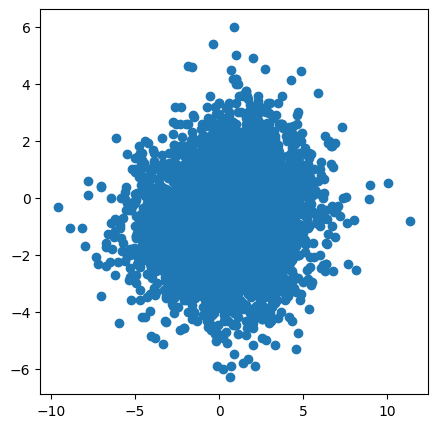

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log2(cnts['clip_enrichment']),
           np.log2(cnts['rden_change']))

# 논문 4D와 비슷한 그림 만들기 
-이미 정규화는 'rden_change = (RPF_siLin28a / RNA_siLin28a) / (RPF_siLuc / RNA_siLuc)'등으로 되어있음

In [34]:
filtered = cnts[
    (cnts['RNA-control.bam'] > 20) &
    (cnts['RNA-siLin28a.bam'] > 20) &
    (cnts['RNA-siLuc.bam'] > 20) &
    (cnts['CLIP-35L33G.bam'] > 5) &
    (cnts['RPF-siLin28a.bam'] > 5) &
    (cnts['RPF-siLuc.bam'] > 5)
]

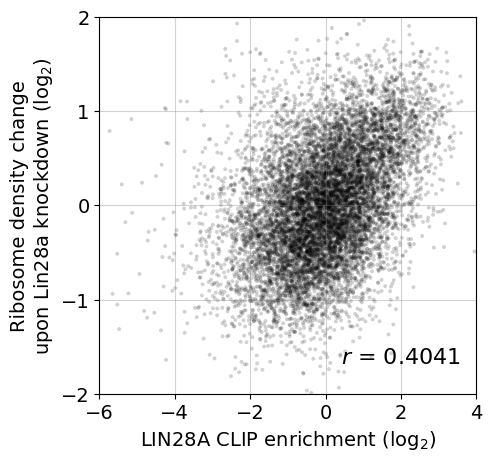

In [36]:

x = np.log2(filtered['clip_enrichment'])
y = np.log2(filtered['rden_change'])
y = y - np.median(y)
x = x - np.median(x)

# NaN 제거
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

# percentile
x_low, x_high = np.percentile(x, [1, 99])
y_low, y_high = np.percentile(y, [1, 99])


# Centering
x = x - np.median(x)
y = y - np.median(y)

# correlation
r = np.corrcoef(x, y)[0, 1]

#plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_box_aspect(1)

ax.scatter(x, y, s=8,c='black', alpha=0.18, edgecolors='none')

ax.set_xlim(-6, 4)
ax.set_ylim(-2, 2)
ax.tick_params(axis='both', labelsize=14)

ax.set_xlabel('LIN28A CLIP enrichment (log$_2$)', fontsize=14)
ax.set_ylabel('Ribosome density change\nupon Lin28a knockdown (log$_2$)', fontsize=14)

ax.set_xticks([-6, -4, -2, 0, 2, 4])
ax.set_yticks([-2, -1, 0, 1, 2])
ax.grid(True, color='gray', alpha=0.35)

ax.text(0.64, 0.08, f'$r$ = {r:.4f}', transform=ax.transAxes, fontsize=16)

plt.tight_layout()
plt.show()

# Protein Localization 반영하기

In [37]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
mouselocal = pd.read_csv('https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt', sep='\t')
mouselocal.head()

,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


In [42]:
# cnts의 index에서 version 제거
cnts = cnts.copy()
cnts['gene_id'] = cnts.index.str.replace(r'\.\d+$', '', regex=True)

# localization 붙이기
cnts_loc = cnts.merge(
    mouselocal[['gene_id', 'type']],
    on='gene_id',
    how='inner'
)

cnts_loc.head()

,Chr,Start,End,Strand,Length,CLIP-35L33G.bam,RNA-control.bam,RNA-siLin28a.bam,RNA-siLuc.bam,RPF-siLin28a.bam,RPF-siLuc.bam,clip_enrichment,rden_change,gene_id,type
0,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0,4.000000,NaN,ENSMUSG00000051951,integral membrane
1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4561154;4561473;4561613;4561936;4562680;456268...,4562891;4562886;4562891;4562891;4563827;456289...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,4772,6,1,8,5,2,3,6.000000,0.416667,ENSMUSG00000025902,nucleus
2,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4878011;4878046;4878053;4878119;4878121;487813...,4878205;4878205;4878205;4878205;4878205;487820...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,7145,2045,574,1219,1236,33,44,3.562718,0.760459,ENSMUSG00000025903,cytoplasm
3,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,4979799;4979799;4980625;4980697;4982537;498253...,4980885;4980885;4980885;4980885;4982771;498277...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,4239,5,1,1,8,3,2,5.000000,12.000000,ENSMUSG00000002459,nucleus
4,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,5658689;5658716;5658716;5658780;5659164;565922...,5661534;5658886;5658886;5658886;5659528;565952...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,9151,49,1,20,20,8,7,49.000000,1.142857,ENSMUSG00000025905,integral membrane


In [43]:
cnts_loc[['gene_id', 'type', 'clip_enrichment', 'rden_change']].head()

,gene_id,type,clip_enrichment,rden_change
0,ENSMUSG00000051951,integral membrane,4.000000,NaN
1,ENSMUSG00000025902,nucleus,6.000000,0.416667
2,ENSMUSG00000025903,cytoplasm,3.562718,0.760459
3,ENSMUSG00000002459,nucleus,5.000000,12.000000
4,ENSMUSG00000025905,integral membrane,49.000000,1.142857


In [50]:
#nts_loc = cnts_loc.sort_values('RNA-control.bam', ascending=False)
#nts_loc = cnts_loc.head(2000)

cnts_loc = cnts_loc.sample(n=2000, random_state=0)

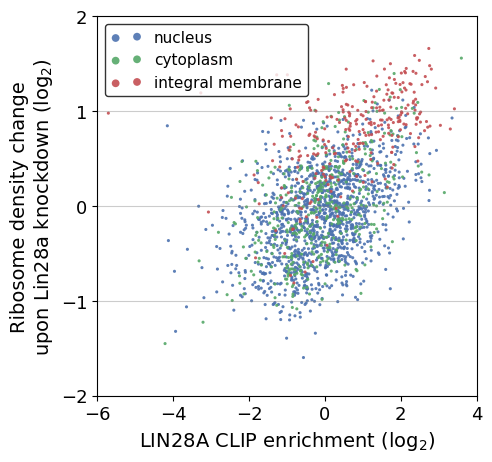

In [57]:
# log2
cnts_loc['x'] = np.log2(cnts_loc['clip_enrichment'])
cnts_loc['y'] = np.log2(cnts_loc['rden_change'])

# NaN, inf 제거
cnts_loc = cnts_loc[
    np.isfinite(cnts_loc['x']) &
    np.isfinite(cnts_loc['y'])
].copy()

# median centering
cnts_loc['x'] = cnts_loc['x'] - cnts_loc['x'].median()
cnts_loc['y'] = cnts_loc['y'] - cnts_loc['y'].median()

# plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_box_aspect(1)

colors = {
    'nucleus': '#4C72B0',
    'cytoplasm': '#55A868',
    'integral membrane': '#C44E52'
}

for loc_type, color in colors.items():
    sub = cnts_loc[cnts_loc['type'] == loc_type]
    
    ax.scatter(
        sub['x'], sub['y'],
        s=5,
        alpha=0.9,
        c=color,
        label=loc_type,
        edgecolors='none'
    )

# 축 설정
ax.set_xlim(-6, 4)
ax.set_ylim(-2, 2)

ax.set_xticks([-6, -4, -2, 0, 2, 4])
ax.set_yticks([-2, -1, 0, 1, 2])

ax.set_xlabel('LIN28A CLIP enrichment (log$_2$)', fontsize=14)
ax.set_ylabel('Ribosome density change\nupon Lin28a knockdown (log$_2$)', fontsize=14)

# 숫자 크기
ax.tick_params(axis='both', labelsize=13)

# 가로 grid만
ax.grid(axis='y', color='gray', alpha=0.4)

# legend 스타일
ax.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=11, loc='upper left', scatterpoints=2,markerscale=2.5)

plt.tight_layout()
plt.show()